# 06 — Time Matrix (Waktu Tempuh Antar Venue)

**Beda dari `time_spent`** (durasi kunjungan DI dalam satu venue, sintetis):
`time_matrix` = waktu tempuh DARI satu venue KE venue lain — dipakai
sebagai constraint fitness GA/PSO (next phase, optimasi rute itinerary).

**Sumber waktu tempuh** (kolom `time_source`):
1. **OSRM** (`router.project-osrm.org`) — rute jalan asli, durasi dari
   response API. Gratis, tanpa API key, TANPA traffic real-time.
2. **Estimated** (fallback) — `haversine / avg_speed_kmh` (asumsi 20 km/jam,
   kondisi macet Jakarta), dipakai kalau OSRM gagal/timeout.

**Scope dibatasi** ke pasangan venue dalam `zone_id` sama (hasil clustering
05) — alasan teknis: OSRM public demo ToS-limited, bukan untuk volume besar
(all-pairs 340 venue = 57.630 pasangan, vs per-zona = 8.183 pasangan).
Alasan logis: itinerary harian biasanya antar venue berdekatan/zona sama.

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import config

In [2]:
tm = pd.read_csv("../../data/processed/time_matrix.csv")
clustered = pd.read_csv("../../data/processed/clustered_venues.csv")

print(f"Total pasangan venue dihitung: {len(tm)}")
print()
print("Sumber waktu tempuh:")
print(tm["time_source"].value_counts())
print()
pct_osrm = (tm["time_source"] == "osrm").mean()
print(f"OSRM sukses: {pct_osrm:.1%} | fallback estimasi: {1 - pct_osrm:.1%}")

Total pasangan venue dihitung: 8183

Sumber waktu tempuh:
time_source
osrm    8183
Name: count, dtype: int64

OSRM sukses: 100.0% | fallback estimasi: 0.0%


## Distribusi waktu tempuh

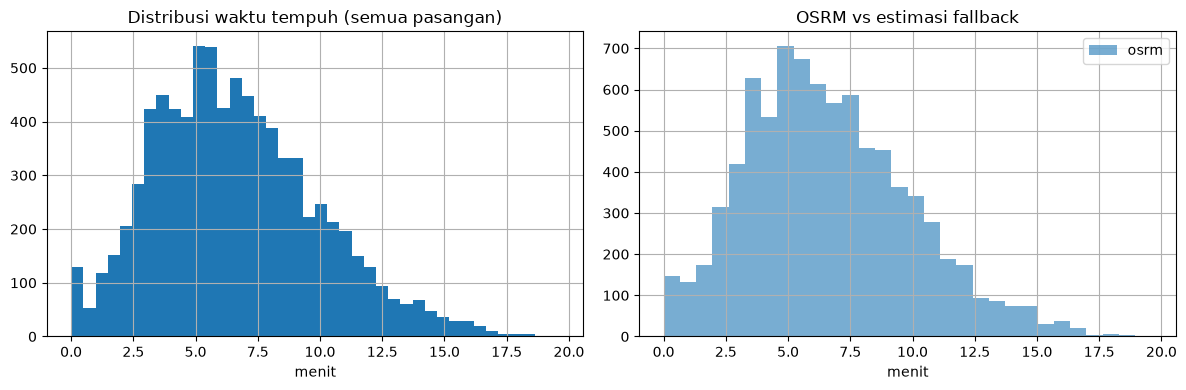

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tm["duration_minutes"].hist(bins=40, ax=axes[0])
axes[0].set_title("Distribusi waktu tempuh (semua pasangan)")
axes[0].set_xlabel("menit")

for src in tm["time_source"].unique():
    tm[tm["time_source"] == src]["duration_minutes"].hist(
        bins=30, ax=axes[1], alpha=0.6, label=src)
axes[1].set_title("OSRM vs estimasi fallback")
axes[1].set_xlabel("menit")
axes[1].legend()
plt.tight_layout()
plt.show()

## Spot-check: OSRM vs estimasi pada pasangan yang sama

Sanity check — waktu tempuh OSRM (rute jalan asli) seharusnya lebih besar
dari estimasi garis lurus (`haversine/speed`) karena jalan tidak lurus.

In [4]:
coord = clustered.set_index("venue_id")[["latitude", "longitude"]]


def haversine_km(a, b):
    from math import radians, sin, cos, asin, sqrt
    lat1, lon1 = coord.loc[a]
    lat2, lon2 = coord.loc[b]
    r = 6371
    dlat, dlon = radians(lat2 - lat1), radians(lon2 - lon1)
    x = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    return 2 * r * asin(sqrt(x))


sample = tm[tm["time_source"] == "osrm"].sample(min(10, len(tm[tm["time_source"] == "osrm"])),
                                                  random_state=config.RANDOM_SEED)
sample = sample.copy()
sample["dist_km"] = sample.apply(lambda r: haversine_km(r["venue_id_a"], r["venue_id_b"]), axis=1)
sample["estimasi_menit"] = sample["dist_km"] / config.AVG_SPEED_KMH_FALLBACK * 60
sample[["venue_id_a", "venue_id_b", "dist_km", "duration_minutes", "estimasi_menit"]]

,venue_id_a,venue_id_b,dist_km,duration_minutes,estimasi_menit
5064,1811,62694,2.826412,10.1,8.479235
7541,26683,55752,3.308764,10.1,9.926293
3011,13290,19069,0.616647,2.9,1.849940
3065,13542,24034,1.704343,7.2,5.113029
1320,10630,15632,0.531554,9.2,1.594662
4355,15609,36720,3.491563,8.8,10.474690
2905,10712,65766,0.248497,4.4,0.745492
5148,7997,29589,3.701582,8.8,11.104746
6261,34525,60444,4.628657,10.9,13.885972
3410,22236,28590,0.699253,2.8,2.097758


## Heatmap waktu tempuh — zona dengan jumlah venue terbanyak

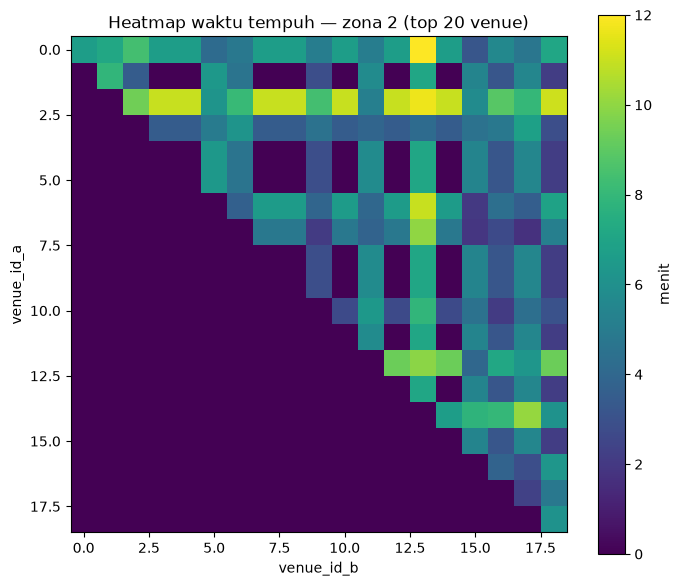

In [5]:
top_zone = clustered["zone_id"].value_counts().idxmax()
ids_zone = clustered[clustered["zone_id"] == top_zone]["venue_id"].tolist()[:20]

sub = tm[tm["venue_id_a"].isin(ids_zone) & tm["venue_id_b"].isin(ids_zone)]
pivot = sub.pivot_table(index="venue_id_a", columns="venue_id_b", values="duration_minutes")

plt.figure(figsize=(8, 7))
plt.imshow(pivot.fillna(0), cmap="viridis")
plt.colorbar(label="menit")
plt.title(f"Heatmap waktu tempuh — zona {top_zone} (top 20 venue)")
plt.xlabel("venue_id_b")
plt.ylabel("venue_id_a")
plt.show()

## Ringkasan

`time_matrix.csv` siap dipakai sebagai constraint fitness GA/PSO (next
phase) — total durasi rute = sum(`time_matrix` antar venue berurutan) +
sum(`time_spent` di tiap venue). Belum diimplementasikan di notebook ini.